# Estimating small-scale aliasing in SWOT Expert L2 LR SSHA spectra 

**Goal.** The SWOT Expert (2 km) SSHA product is generated from the Unsmoothed (~250 mposted) product by applying a 17-point Hamming smoother (2D), with a half-power cutoff wavelength of ~6.28 km (Chelton 2024), and evaluating the smoothed field
directly at the 2 km grid locations. Because the Hamming filter is not a brick-wall low-pass filter, some power at wavelengths shorter than the Expert grid's Nyquist wavelength (4 km) could survive filtering and fold back into the resolved wavenumber band when the
data are decimated to 2 km.

This notebook documents the estimation of how much of the Expert product's small-scale spectral power (wavelengths just longer than 4 km, and extending up toward 10-50 km) can be attributed to aliasing, versus genuine filtered ocean/noise signal.


## Filter description

Filter transfer function (1D, N=17-point Hamming window, native spacing $\Delta x_0$ = 250 m):

$$
H(k) = \sum_{n=0}^{16} h_n\, e^{-i 2\pi k\, n \Delta x_0}, \qquad
h[n] = \frac{w_n}{\sum_n w_n}, \qquad
w[n] = 0.54 - 0.46\cos\!\left(\frac{2\pi n}{16}\right)
$$


"Alias-free" prediction:

$$
S_{\text{no-alias}}(k) = |H(k)|^2 \, S_{\text{unsmoothed}}(k)
$$

## Estimating aliasing

Full folded (aliased) spectrum actually observed at 2 km (Poisson summation / sampling theorem), with sampling frequency $f_s = 1/\Delta x = 0.5\ \text{cpkm}$ and
Nyquist $k_{Nyq} = 0.25\ \text{cpkm}$ (4 km wavelength):

$$
S_{\text{2km}}(k) = \sum_{m=-\infty}^{\infty} |H(k + m f_s)|^2\, S_{\text{unsmoothed}}(k + m f_s),
\qquad |k| \le k_{Nyq}
$$

An empirical aliasing estimate would be:

$$
\text{Aliasing}(k) \;\approx\; S_{\text{Expert, observed}}(k) \;-\; |H(k)|^2\, S_{\text{unsmoothed}}(k)
$$

 or, alternatively:
 
$$
\text{Aliasing}(k) \;\approx\; \frac{S_{\text{Expert, observed}}(k)} {|H(k)|^2\, S_{\text{unsmoothed}}(k)}
$$

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path
from scipy.signal import welch, get_window, fftconvolve

import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

In [2]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
EXPERT_FILE     = 'SWOT_L2_LR_SSH_Expert_0524/SWOT_L2_LR_SSH_Expert_016_074_20240531T192537_20240531T201622_PGD0_01.nc'
UNSMOOTHED_FILE = 'SWOT_L2_LR_SSH_Unsmoothed_016_074_20240531T192538_20240531T201625_PGD0_01.nc'

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 1000.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25
DETREND = 'constant'
# ── Box size ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = -60.0,60.0, 0.0, 360.0
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = True   # add internal tide correction (height_cor_xover + internal_tide_hret)



In [3]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset."""
    if not all_segments:
        raise ValueError('No segments to pack.')
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': 'Along-track SSH(A) PSD',
                  'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments],
                      {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments],
                     {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments],
                     {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments],
                      {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            #granule=(['segment'], [s._granule for s in all_segments]),
            #year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
            #      {'long_name': 'Year of the source SWOT sub-directory'}),
            #month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
            #       {'long_name': 'Month of the source SWOT sub-directory'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        ),
    )


def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [4]:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=HRET)

ds_unsmooth_left = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='left')
ds_unsmooth_right = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='right')

ds_unsmooth_left  = ds_unsmooth_left.assign_coords({'num_pixels':ds_unsmooth_left.num_pixels})
ds_unsmooth_right = ds_unsmooth_right.assign_coords({'num_pixels':ds_unsmooth_right.num_pixels+ds_unsmooth_right.num_pixels.values[-1]+1})
ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3039970212.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3039970212.py:8: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) 

In [5]:
ssha = (ds_unsmooth[SSH_VAR] + ds_unsmooth['height_cor_xover'])
for qual_name in (f'{SSH_VAR}_qual', 'ssha_karin_2_qual', 'ssh_karin_2_qual'):
    if qual_name in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[qual_name] == 0)
        break
for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
    if scf in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[scf] == 0)
        break
if 'surface_type' in ds_unsmooth.variables:
    ssha = ssha.where(ds_unsmooth['surface_type'] == 0)
    #ssha = np.ma.masked_where(np.abs(ssha)<2,ssha).data
mask = np.where((ssha<2.0)&(ssha>-2.0))
lat = ds_unsmooth['latitude'].values
lon = ds_unsmooth['longitude'].values
xtrack = np.array(ds_unsmooth['cross_track_distance'], dtype='float64')
xtrack = ds_unsmooth['cross_track_distance'].values
ssha = ssha.where(np.abs(ssha)<2.0)

data_unsmoothed = {'ssha': ssha.values, 'latitude': lat,'longitude': lon,'cross_track_distance': xtrack}

In [6]:
def process_one_file(data, segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max):
    import traceback as _tb

    try:
        result = compute_pass_spectra(
            ssha=data['ssha'],
            latitude=data['latitude'],
            longitude=data['longitude'],
            cross_track_distance=data['cross_track_distance'],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend
        )
    except Exception:
        return ( f'spectra error:\n{_tb.format_exc()}', None)

    #granule_name = Path(filepath).stem
    kept, wavenumber = [], None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                #seg._granule = granule_name
                kept.append(seg)

    return (kept, wavenumber)

In [7]:
processed_expert   = process_one_file(data_expert,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX
                                      )

In [8]:
processed_unsmooth = process_one_file(data_unsmoothed,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX
                                      )

In [9]:
all_segments_expert, k_expert  = processed_expert
all_segments_unsmooth, k_unsmoothed = processed_unsmooth

In [10]:
ds_segments_expert     = segments_to_dataset(all_segments_expert, k_expert)
ds_segments_unsmoothed = segments_to_dataset(all_segments_unsmooth, k_unsmoothed)
print(f'Segment dataset (expert): {ds_segments_expert.sizes}')
print(f'Segment dataset (unsmoothed): {ds_segments_unsmoothed.sizes}')

Segment dataset (expert): Frozen({'segment': 34, 'wavenumber': 251})
Segment dataset (unsmoothed): Frozen({'segment': 36, 'wavenumber': 2098})


In [11]:
S_unsmoothed = ds_segments_unsmoothed.mean('segment').psd
S_expert = ds_segments_expert.mean('segment').psd

In [12]:
# Native (Unsmoothed) and Expert grid spacings
DX_NATIVE_KM = 0.25   # ~250 m posting
DX_EXPERT_KM = 2.0    # 2 km posting

# Hamming filter parameters (Chelton 2024)
N_TAPS = 17
HALF_POWER_WAVELENGTH_KM = 6.28  # nominal half-power cutoff wavelength

In [13]:
def hamming_1d_weights(n_taps=N_TAPS):
    n = np.arange(n_taps)
    w = 0.54 - 0.46 * np.cos(2 * np.pi * n / (n_taps - 1))
    h = w / w.sum()
    return h

def transfer_function_1d(k_cpkm, dx_km=DX_NATIVE_KM, n_taps=N_TAPS):
    """DTFT magnitude of the 1D Hamming window at wavenumbers k (cycles/km).
    Used for both kx and ky since the 2D filter is separable."""
    h = hamming_1d_weights(n_taps)
    n = np.arange(n_taps) - (n_taps - 1) / 2.0
    Hk = np.array([np.sum(h * np.exp(-1j * 2 * np.pi * kk * n * dx_km)) for kk in np.atleast_1d(k_cpkm)])
    return Hk

H_check = np.abs(transfer_function_1d(k_unsmoothed)) ** 2
k_half_power_theory  = 1.0 / HALF_POWER_WAVELENGTH_KM
k_half_power_numeric = k_unsmoothed[np.argmin(np.abs(H_check - 0.5))]
print(f"theoretical half-power k = {k_half_power_theory:.3f} cpkm  (wavelength {1/k_half_power_theory:.2f} km)")
print(f"numeric      half-power k = {k_half_power_numeric:.3f} cpkm  (wavelength {1/k_half_power_numeric:.2f} km)")

S_no_alias_naive = H_check * S_unsmoothed

theoretical half-power k = 0.159 cpkm  (wavelength 6.28 km)
numeric      half-power k = 0.159 cpkm  (wavelength 6.29 km)


In [14]:
CROSS_TRACK_START_IDX, CROSS_TRACK_END_IDX = 5,230
CROSS_TRACK_START_IDX_EXPERT, CROSS_TRACK_END_IDX_EXPERT = 5,30
# --- 2D patch of Unsmoothed data (along-track x cross-track) ---
n_along_samples = int(SEGMENT_LENGTH_KM / DX_NATIVE_KM)
cross_track_slice = slice(CROSS_TRACK_START_IDX, CROSS_TRACK_END_IDX)  # user-defined

patch_da = ds_unsmooth["ssha_karin_2"].isel(
    num_lines=slice(0, n_along_samples), num_pixels=cross_track_slice
)

def clean_2d(da):
    """Detrend along the along-track axis (axis 0) at each cross-track column;
    handle/interpolate small NaN gaps beforehand as needed for your data."""
    x = da#.values.astype(float)
    n_along, n_cross = x.shape
    idx = np.arange(n_along)
    for j in range(n_cross):
        col = x[:, j]
        if np.all(np.isfinite(col)):
            x[:, j] = col - np.polyval(np.polyfit(idx, col, 1), idx)
    return x

patch_2d = clean_2d(patch_da)
print("2D Unsmoothed patch shape (along-track, cross-track):", patch_2d.shape)

# --- Matching 2D patch of the *actual* Expert product ---
n_along_samples_expert = int(SEGMENT_LENGTH_KM / DX_EXPERT_KM)
cross_track_slice_expert = slice(CROSS_TRACK_START_IDX_EXPERT, CROSS_TRACK_END_IDX_EXPERT)  # user-defined
patch_expert_da = data_expert["ssha"][0:n_along_samples_expert,CROSS_TRACK_START_IDX_EXPERT:CROSS_TRACK_END_IDX_EXPERT]
patch_expert_2d = clean_2d(patch_expert_da)
print("2D Expert patch shape (along-track, cross-track):", patch_expert_2d.shape)

2D Unsmoothed patch shape (along-track, cross-track): (4000, 225)
2D Expert patch shape (along-track, cross-track): (500, 25)


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3859871623.py:42: RuntimeWarning: divide by zero encountered in divide
  ax.loglog(1/k_unsmoothed, S_unsmoothed,        label="Unsmoothed (measured, 1D)", color="gray", alpha=0.6)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3859871623.py:43: RuntimeWarning: divide by zero encountered in divide
  ax.loglog(1/k_unsmoothed, S_no_alias_naive,     label="Naive 1D-only prediction (biased high)", ls="--")
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3859871623.py:44: RuntimeWarning: divide by zero encountered in divide
  ax.loglog(1/k_unsmoothed, S_no_alias_corrected, label="Analytic dealiased (2D-based) prediction")
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_48055/3859871623.py:45: RuntimeWarning: divide by zero encountered in divide
  ax.loglog(1/k_expert,     S_expert,             label="Expert (observed)")


Text(0.5, 1.0, 'Naive vs. analytic dealiased prediction vs. observed Expert spectrum')

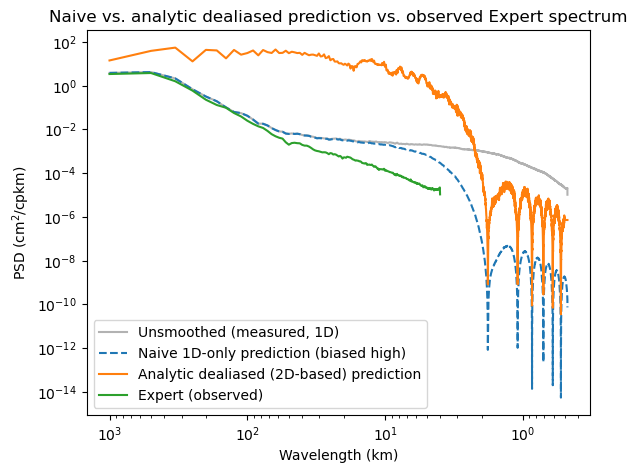

In [15]:
def psd_2d(patch, dx_along_km, dx_cross_km, window="hann"):
    """2D periodogram of a detrended SSHA patch [n_along, n_cross].
    Returns kx [cpkm], ky [cpkm], S2D [units^2 / cpkm^2] (fftshifted, both axes)."""
    n_along, n_cross = patch.shape
    wx = get_window(window, n_along)
    wy = get_window(window, n_cross)
    win2d = np.outer(wx, wy)
    win_norm = np.sum(win2d ** 2)

    F = np.fft.fft2(patch * win2d)
    F = np.fft.fftshift(F)
    S2D = (np.abs(F) ** 2) * (dx_along_km * dx_cross_km) / win_norm

    kx = np.fft.fftshift(np.fft.fftfreq(n_along, d=dx_along_km))
    ky = np.fft.fftshift(np.fft.fftfreq(n_cross, d=dx_cross_km))
    return kx, ky, S2D

kx_2d, ky_2d, S2D_unsmoothed = psd_2d(patch_2d, DX_NATIVE_KM, DX_NATIVE_KM)

Hx2 = np.abs(transfer_function_1d(kx_2d, DX_NATIVE_KM)) ** 2
Hy2 = np.abs(transfer_function_1d(ky_2d, DX_NATIVE_KM)) ** 2

dky = ky_2d[1] - ky_2d[0]
S2D_ky_filtered = S2D_unsmoothed * Hy2[np.newaxis, :]
S_ky_integrated = np.sum(S2D_ky_filtered, axis=1) * dky   # shape (n_along,), pre-Hx2

S_no_alias_corrected_full = Hx2 * S_ky_integrated

pos = kx_2d >= 0
kx_pos = kx_2d[pos]
S_ky_integrated_pos = S_ky_integrated[pos]
S_no_alias_corrected_pos = S_no_alias_corrected_full[pos]

S_no_alias_corrected = np.interp(k_unsmoothed, kx_pos, S_no_alias_corrected_pos)

k_nyq_expert = 1.0 / (2 * DX_EXPERT_KM)  # 0.25 cpkm
mask = k_unsmoothed <= k_nyq_expert
k_common = k_unsmoothed[mask]
S_no_alias_common = S_no_alias_corrected[mask]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.loglog(1/k_unsmoothed, S_unsmoothed,        label="Unsmoothed (measured, 1D)", color="gray", alpha=0.6)
ax.loglog(1/k_unsmoothed, S_no_alias_naive,     label="Naive 1D-only prediction (biased high)", ls="--")
ax.loglog(1/k_unsmoothed, S_no_alias_corrected, label="Analytic dealiased (2D-based) prediction")
ax.loglog(1/k_expert,     S_expert,             label="Expert (observed)")
ax.invert_xaxis()
ax.set_xlabel("Wavelength (km)")
ax.set_ylabel("PSD (cm$^2$/cpkm)")
ax.legend()
ax.set_title("Naive vs. analytic dealiased prediction vs. observed Expert spectrum")

In [16]:
DECIM_FACTOR = int(round(DX_EXPERT_KM / DX_NATIVE_KM))  # 8
def hamming_2d_kernel(n_taps=N_TAPS):
    h1d = hamming_1d_weights(n_taps)
    return np.outer(h1d, h1d)

def filter_and_decimate_2d(patch, decim_factor=DECIM_FACTOR, n_taps=N_TAPS):
    K = hamming_2d_kernel(n_taps)
    filtered = fftconvolve(patch, K, mode="same")
    half = n_taps // 2
    filtered_valid = filtered[half:-half, half:-half] if half > 0 else filtered
    decimated = filtered_valid[::decim_factor, ::decim_factor]
    return decimated

patch_emulated_2km = filter_and_decimate_2d(patch_2d)
print("Emulated 2 km patch shape (along-track, cross-track):", patch_emulated_2km.shape)

S_emulated_cols = []
k_emulated = None
for j in range(patch_emulated_2km.shape[1]):
    col = patch_emulated_2km[:, j]
    col = col - np.polyval(np.polyfit(np.arange(len(col)), col, 1), np.arange(len(col)))
    k_e, S_e = psd_1d(col, DX_EXPERT_KM)
    k_emulated = k_e
    S_emulated_cols.append(S_e)
S_emulated = np.mean(S_emulated_cols, axis=0)

S_expert_patch_cols = []
for j in range(patch_expert_2d.shape[1]):
    col = patch_expert_2d[:, j]
    col = col - np.polyval(np.polyfit(np.arange(len(col)), col, 1), np.arange(len(col)))
    k_ep, S_ep = psd_1d(col, DX_EXPERT_KM)
    S_expert_patch_cols.append(S_ep)
S_expert_patch_avg = np.mean(S_expert_patch_cols, axis=0)

S_no_alias_on_emulated_grid = np.interp(k_emulated, k_unsmoothed, S_no_alias_corrected)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].loglog(1/k_emulated, S_emulated,                  label="Emulated (conv+decimate)")
axes[0].loglog(1/k_emulated, S_no_alias_on_emulated_grid, label="Analytic dealiased prediction", ls="--")
axes[0].loglog(1/k_emulated, S_expert_patch_avg[1:],          label="Real Expert (same patch)")
axes[0].invert_xaxis()
axes[0].set_xlabel("Wavelength (km)"); axes[0].set_ylabel("PSD (cm$^2$/cpkm)")
axes[0].legend(fontsize=8)
axes[0].set_title("Emulated vs. analytic prediction vs. real Expert")

aliasing_numeric_selfcontained = S_emulated - S_no_alias_on_emulated_grid
axes[1].semilogx(1/k_emulated, aliasing_numeric_selfcontained)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].invert_xaxis()
axes[1].set_xlabel("Wavelength (km)"); axes[1].set_ylabel("Excess PSD (cm$^2$/cpkm)")
axes[1].set_title("Numerically exact aliasing estimate")
plt.tight_layout()

Emulated 2 km patch shape (along-track, cross-track): (498, 27)


NameError: name 'psd_1d' is not defined

In [71]:
#Better 2D filter
nx = 4000
ny=512
kx = np.fft.fftfreq(nx, d=DX_NATIVE_KM)
ky = np.fft.fftfreq(ny, d=DX_NATIVE_KM)

H2D = transfer_function_2d(kx, ky)
H2D_power = np.abs(H2D)**2

In [72]:
S2D_filtered = S2D * np.abs(H2D)**2

NameError: name 'S2D' is not defined

In [66]:
S_unsmoothed = ds_segments_unsmoothed.mean('segment').psd
S_expert = ds_segments_expert.mean('segment').psd


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/677825216.py:18: RuntimeWarning: divide by zero encountered in divide
  axes[0].loglog(1 / k_common, S_expert_interp, label="Expert (observed)")
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/677825216.py:19: RuntimeWarning: divide by zero encountered in divide
  axes[0].loglog(1 / k_unsmoothed, S_unsmoothed, label="Unsmoothed (observed)")
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/677825216.py:20: RuntimeWarning: divide by zero encountered in divide
  axes[0].loglog(1 / k_common, S_no_alias_common,
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/677825216.py:28: RuntimeWarning: divide by zero encountered in divide
  axes[1].semilogx(1 / k_common, aliasing_estimate)


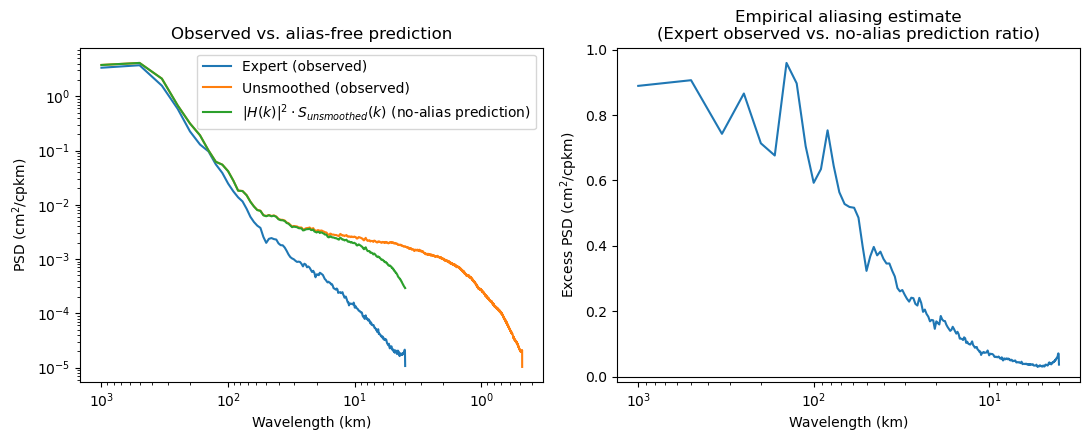

In [59]:
# Alias-free prediction, evaluated on the unsmoothed wavenumber grid
S_no_alias = H2_simple * S_unsmoothed

# Restrict to the Expert product's resolvable band (|k| <= 0.25 cpkm)
k_nyq_expert = 1.0 / (2 * DX_EXPERT_KM)  # 0.25 cpkm
mask = k_unsmoothed <= k_nyq_expert

k_common = k_unsmoothed[mask]
S_no_alias_common = S_no_alias[mask]

# Interpolate the observed Expert spectrum onto this same k grid
S_expert_interp = np.interp(k_common, k_expert, S_expert)

aliasing_estimate = S_expert_interp / S_no_alias_common

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].loglog(1 / k_common, S_expert_interp, label="Expert (observed)")
axes[0].loglog(1 / k_unsmoothed, S_unsmoothed, label="Unsmoothed (observed)")
axes[0].loglog(1 / k_common, S_no_alias_common,
               label=r"$|H(k)|^2 \cdot S_{unsmoothed}(k)$ (no-alias prediction)")
axes[0].invert_xaxis()
axes[0].set_xlabel("Wavelength (km)")
axes[0].set_ylabel("PSD (cm$^2$/cpkm)")
axes[0].legend()
axes[0].set_title("Observed vs. alias-free prediction")

axes[1].semilogx(1 / k_common, aliasing_estimate)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].invert_xaxis()
axes[1].set_xlabel("Wavelength (km)")
axes[1].set_ylabel("Excess PSD (cm$^2$/cpkm)")
axes[1].set_title("Empirical aliasing estimate\n(Expert observed vs. no-alias prediction ratio)")

plt.tight_layout()

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/1454754200.py:23: RuntimeWarning: divide by zero encountered in divide
  ax.semilogx(1 / k_common, aliasing_estimate, label="Empirical (Expert minus prediction)")
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_41198/1454754200.py:24: RuntimeWarning: divide by zero encountered in divide
  ax.semilogx(1 / k_common, aliasing_folding, label="Folding-sum estimate", ls="--")


Text(0.5, 1.0, 'Empirical vs. analytic (folding-sum) aliasing estimate')

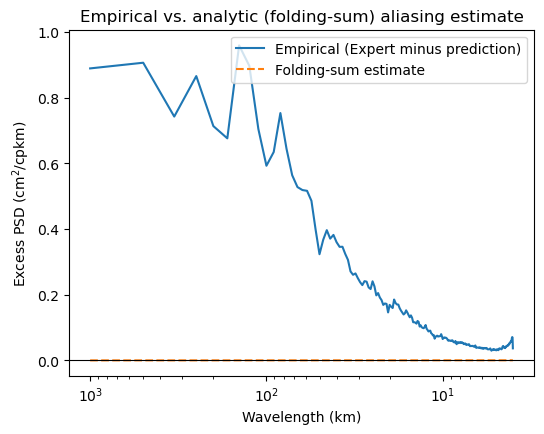

In [67]:
def folding_sum(k_common, k_unsmoothed, S_unsmoothed, H2_func, fs=0.5, m_range=range(-3, 4)):
    """Approximate S_2km(k) via Poisson-summation folding, excluding the m=0
    (non-aliased) term, i.e. returns the aliasing contribution only."""
    alias_only = np.zeros_like(k_common)
    for m in m_range:
        if m == 0:
            continue
        k_shifted = k_common + m * fs
        # Only include shifted wavenumbers within the range actually resolved
        # by the unsmoothed product (avoid extrapolating past its own Nyquist).
        valid = (np.abs(k_shifted) <= k_unsmoothed.max())
        S_shifted = np.interp(np.abs(k_shifted), k_unsmoothed, S_unsmoothed,
                               left=np.nan, right=np.nan)
        H2_shifted = H2_func(np.abs(k_shifted))
        contribution = np.where(valid, H2_shifted * S_shifted, 0.0)
        alias_only += np.nan_to_num(contribution)
    return alias_only

H2_func = lambda k: np.abs(transfer_function_1d(k)) ** 2
aliasing_folding = folding_sum(k_common, k_unsmoothed, S_unsmoothed, H2_func)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.semilogx(1 / k_common, aliasing_estimate, label="Empirical (Expert minus prediction)")
ax.semilogx(1 / k_common, aliasing_folding, label="Folding-sum estimate", ls="--")
ax.axhline(0, color="k", lw=0.8)
ax.invert_xaxis()
ax.set_xlabel("Wavelength (km)")
ax.set_ylabel("Excess PSD (cm$^2$/cpkm)")
ax.legend()
ax.set_title("Empirical vs. analytic (folding-sum) aliasing estimate")